# Skin Condition Classification - Transfer Learning with ResNet50 (v2 - Improved)
### Classes: Acne | Eczema | Alopecia | Healthy
### Changes: stronger augmentation · boosted alopecia weight · fine-tuning phase · BatchNorm head
---

## Step 1: Import Libraries
> **CHANGED**: added `ReduceLROnPlateau` callback import

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ── Numeric / visualization ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau  # ADDED ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── Scikit-learn (class weights) ──────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

# Force CPU – avoids CUDA / GPU issues on most Windows machines
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"Devices available  : {tf.config.list_physical_devices()}")

TensorFlow version : 2.20.0
Devices available  : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Step 2: Configuration / Hyperparameters
> **CHANGED**: `EPOCHS` → 20, added `FINETUNE_LR` and `FINETUNE_EPOCHS` for Phase 2

In [6]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = r"C:\Users\GAURAV\Major Project Code\ml\data\final"
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
VAL_DIR    = os.path.join(BASE_DIR, "val")
TEST_DIR   = os.path.join(BASE_DIR, "test")

# Model checkpoint save path
CHECKPOINT_PATH      = r"C:\Users\GAURAV\Major Project Code\ml\trial\trial2\best_skin_model.keras"
CHECKPOINT_PATH_FT   = r"C:\Users\GAURAV\Major Project Code\ml\trial\trial2\best_skin_model_finetuned.keras"  # NEW – fine-tune checkpoint

# ── Image settings ────────────────────────────────────────────────────────────
IMG_HEIGHT  = 224
IMG_WIDTH   = 224
IMG_SHAPE   = (IMG_HEIGHT, IMG_WIDTH, 3)

# ── Training settings ─────────────────────────────────────────────────────────
BATCH_SIZE    = 16
EPOCHS        = 20           # CHANGED: was 10 → 20 (Phase 1)
LEARNING_RATE = 1e-4         # Phase 1 LR (frozen base)

# ADDED – Phase 2 (fine-tuning) settings
FINETUNE_LR     = 1e-5       # Much lower LR to avoid destroying pretrained weights
FINETUNE_EPOCHS = 10         # Additional epochs for fine-tuning (total ~30)
FINETUNE_AT     = 140        # Unfreeze ResNet50 layers FROM this index onward
                             # ResNet50 has 175 layers; 140 keeps early/mid layers frozen

# ── Class names (must match folder names exactly) ─────────────────────────────
CLASS_NAMES = ['acne', 'alopecia', 'eczema', 'healthy']
NUM_CLASSES = len(CLASS_NAMES)

print("Configuration loaded successfully.")
print(f"  Train dir       : {TRAIN_DIR}")
print(f"  Val dir         : {VAL_DIR}")
print(f"  Test dir        : {TEST_DIR}")
print(f"  Classes         : {CLASS_NAMES}")
print(f"  Phase 1 epochs  : {EPOCHS}   (LR={LEARNING_RATE})")
print(f"  Phase 2 epochs  : {FINETUNE_EPOCHS} (LR={FINETUNE_LR})")

Configuration loaded successfully.
  Train dir       : C:\Users\GAURAV\Major Project Code\ml\data\final\train
  Val dir         : C:\Users\GAURAV\Major Project Code\ml\data\final\val
  Test dir        : C:\Users\GAURAV\Major Project Code\ml\data\final\test
  Classes         : ['acne', 'alopecia', 'eczema', 'healthy']
  Phase 1 epochs  : 20   (LR=0.0001)
  Phase 2 epochs  : 10 (LR=1e-05)


## Step 3: Data Loading with ImageDataGenerator
> **CHANGED**: stronger augmentation — added `brightness_range`, `shear_range`, increased `rotation_range` to 30

In [7]:
# ── Training generator (IMPROVED augmentation) ────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    horizontal_flip    = True,
    vertical_flip      = True,           # ADDED: skin lesions have no fixed orientation
    rotation_range     = 30,             # CHANGED: was 20 → 30
    zoom_range         = 0.20,           # CHANGED: was 0.15 → 0.20
    width_shift_range  = 0.15,           # CHANGED: was 0.1 → 0.15
    height_shift_range = 0.15,           # CHANGED: was 0.1 → 0.15
    shear_range        = 0.10,           # ADDED: slight shearing
    brightness_range   = [0.8, 1.2],     # ADDED: simulate different lighting
    fill_mode          = 'nearest'
)

# ── Validation & Test generators (NO augmentation – only rescaling) ────────────
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# ── Flow from directory ────────────────────────────────────────────────────────
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (IMG_HEIGHT, IMG_WIDTH),
    color_mode   = 'rgb',
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    shuffle      = True,
    seed         = 42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size  = (IMG_HEIGHT, IMG_WIDTH),
    color_mode   = 'rgb',
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    shuffle      = False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size  = (IMG_HEIGHT, IMG_WIDTH),
    color_mode   = 'rgb',
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    shuffle      = False
)

print("Class indices:", train_generator.class_indices)
print(f"Train samples : {train_generator.samples}")
print(f"Val samples   : {val_generator.samples}")
print(f"Test samples  : {test_generator.samples}")

Found 1474 images belonging to 4 classes.
Found 314 images belonging to 4 classes.
Found 320 images belonging to 4 classes.
Class indices: {'acne': 0, 'alopecia': 1, 'eczema': 2, 'healthy': 3}
Train samples : 1474
Val samples   : 314
Test samples  : 320


## Step 4: Handle Class Imbalance
> **CHANGED**: after computing balanced weights, alopecia weight is boosted by 1.5× to specifically fix its low recall

In [8]:
# Compute balanced class weights
raw_labels    = train_generator.classes
unique_labels = np.unique(raw_labels)

class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes      = unique_labels,
    y            = raw_labels
)

class_weights = dict(enumerate(class_weights_array))

# ADDED – Find the alopecia index dynamically and boost its weight
# This directly addresses the low alopecia recall (~0.15)
alopecia_idx = train_generator.class_indices.get('alopecia', None)
if alopecia_idx is not None:
    class_weights[alopecia_idx] *= 1.5   # Give alopecia 50% extra penalty
    print(f"Alopecia (class {alopecia_idx}) weight boosted by 1.5×")

print("\nFinal class weights:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  Class {idx} ({name:10s}) -> weight = {class_weights[idx]:.4f}")

Alopecia (class 1) weight boosted by 1.5×

Final class weights:
  Class 0 (acne      ) -> weight = 0.9259
  Class 1 (alopecia  ) -> weight = 1.9812
  Class 2 (eczema    ) -> weight = 1.0236
  Class 3 (healthy   ) -> weight = 0.8432


## Step 5: Build the Model (ResNet50 + Improved Custom Head)
> **CHANGED**: added `BatchNormalization` after Dense layer; dropout increased to 0.5

In [9]:
def build_model(input_shape, num_classes, learning_rate):
    """
    Transfer-learning model: frozen ResNet50 base + improved classification head.

    Architecture:
        Input (224x224x3)
        └─ ResNet50 base (weights=imagenet, fully frozen in Phase 1)
           └─ GlobalAveragePooling2D
              └─ Dense(512, relu)          ← CHANGED: was 256 → 512
                 └─ BatchNormalization     ← ADDED: stabilises training
                    └─ Dropout(0.5)        ← CHANGED: was 0.4 → 0.5
                       └─ Dense(256, relu) ← ADDED: extra layer for capacity
                          └─ Dropout(0.3)
                             └─ Dense(num_classes, softmax)
    """

    # ── 1. Load ResNet50 base ──────────────────────────────────────────────────
    base_model = ResNet50(
        weights     = 'imagenet',
        include_top = False,
        input_shape = input_shape
    )
    # Freeze ALL base layers for Phase 1
    base_model.trainable = False

    print(f"Base model layers : {len(base_model.layers)}")
    print(f"Base model output : {base_model.output_shape}")

    # ── 2. Build improved classification head ─────────────────────────────────
    inputs = keras.Input(shape=input_shape, name='input_image')
    x = base_model(inputs, training=False)          # BN layers stay in inference mode

    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # First FC block – larger capacity
    x = layers.Dense(512, activation='relu', name='fc_512')(x)   # CHANGED: 256→512
    x = layers.BatchNormalization(name='bn_1')(x)                  # ADDED: stabilise
    x = layers.Dropout(0.5, name='dropout_1')(x)                  # CHANGED: 0.4→0.5

    # Second FC block – added for extra representation capacity
    x = layers.Dense(256, activation='relu', name='fc_256')(x)    # ADDED
    x = layers.Dropout(0.3, name='dropout_2')(x)                  # ADDED

    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    # ── 3. Assemble & compile ─────────────────────────────────────────────────
    model = Model(inputs=inputs, outputs=outputs, name='skin_classifier_v2')

    model.compile(
        optimizer = Adam(learning_rate=learning_rate),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )
    return model


model = build_model(
    input_shape   = IMG_SHAPE,
    num_classes   = NUM_CLASSES,
    learning_rate = LEARNING_RATE
)
model.summary()

Base model layers : 175
Base model output : (None, 7, 7, 2048)


Model: "skin_classifier_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)         │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc_512 (Dense)                       │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_1 (BatchNormalization)            │ (None, 512)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc_256 (Dense)                       │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,771,204 (94.49 MB)

 Trainable params: 1,182,468 (4.51 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

## Step 6: Define Callbacks (Phase 1)
> **CHANGED**: added `ReduceLROnPlateau` to automatically halve LR on plateau

In [10]:
early_stopping = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 5,              # CHANGED: was 4 → 5 (more tolerance)
    restore_best_weights = True,
    verbose              = 1
)

model_checkpoint = ModelCheckpoint(
    filepath        = CHECKPOINT_PATH,
    monitor         = 'val_accuracy',
    save_best_only  = True,
    mode            = 'max',
    verbose         = 1
)

# ADDED – Halve LR when val_loss stops improving for 3 epochs
reduce_lr = ReduceLROnPlateau(
    monitor   = 'val_loss',
    factor    = 0.5,
    patience  = 3,
    min_lr    = 1e-7,
    verbose   = 1
)

callbacks_phase1 = [early_stopping, model_checkpoint, reduce_lr]

print("Phase 1 callbacks ready.")

Phase 1 callbacks ready.


## Step 7: Train – Phase 1 (Frozen Base)

In [11]:
print("=" * 55)
print("  PHASE 1: Training with frozen ResNet50 base")
print(f"  Epochs: {EPOCHS}  |  LR: {LEARNING_RATE}")
print("=" * 55)

history_phase1 = model.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = val_generator,
    class_weight    = class_weights,
    callbacks       = callbacks_phase1,
    verbose         = 1
)

print("\nPhase 1 training complete.")

  PHASE 1: Training with frozen ResNet50 base
  Epochs: 20  |  LR: 0.0001
Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4060 - loss: 1.3497
Epoch 1: val_accuracy improved from None to 0.29618, saving model to C:\Users\GAURAV\Major Project Code\ml\trial\trial2\best_skin_model.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.4701 - loss: 1.2511 - val_accuracy: 0.2962 - val_loss: 1.4345 - learning_rate: 1.0000e-04
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5553 - loss: 1.1299
Epoch 2: val_accuracy improved from 0.29618 to 0.55732, saving model to C:\Users\GAURAV\Major Project Code\ml\trial\trial2\best_skin_model.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.5780 - loss: 1.0955 - val_accuracy: 0.5573 - val_loss: 1.2650 - learning_rate: 1.0000e-04
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6182 - loss: 1.0044
Epoch 3: val_accuracy improved from 0.55732 to 0.63376, saving model to C:\Users\GAURAV\Major Project 

## Step 7b: Fine-Tuning – Phase 2 (Unfreeze Top ResNet50 Layers)
> **NEW CELL** – unfreeze the last ~35 ResNet50 layers and retrain at a very low LR

In [12]:
# ── Retrieve the ResNet50 base from inside the model ─────────────────────────
base_model = model.get_layer('resnet50')   # Name assigned by Keras internally

# Unfreeze the whole base first, then re-freeze early layers
base_model.trainable = True

# Freeze all layers BEFORE index FINETUNE_AT (keep low-level features frozen)
for layer in base_model.layers[:FINETUNE_AT]:
    layer.trainable = False

# Count how many layers are now trainable
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Fine-tuning: {trainable_count} ResNet50 layers unfrozen "
      f"(layers {FINETUNE_AT}–{len(base_model.layers)})")

# ── Re-compile at a MUCH lower learning rate ─────────────────────────────────
# Using a fresh Adam with 1e-5 prevents destroying the pretrained weights
model.compile(
    optimizer = Adam(learning_rate=FINETUNE_LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── Callbacks for Phase 2 ─────────────────────────────────────────────────────
early_stopping_ft = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1
)

model_checkpoint_ft = ModelCheckpoint(
    filepath       = CHECKPOINT_PATH_FT,   # Separate checkpoint for fine-tuned model
    monitor        = 'val_accuracy',
    save_best_only = True,
    mode           = 'max',
    verbose        = 1
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 3,
    min_lr   = 1e-8,
    verbose  = 1
)

callbacks_phase2 = [early_stopping_ft, model_checkpoint_ft, reduce_lr_ft]

print("=" * 55)
print("  PHASE 2: Fine-tuning top ResNet50 layers")
print(f"  Epochs: {FINETUNE_EPOCHS}  |  LR: {FINETUNE_LR}")
print("=" * 55)

history_phase2 = model.fit(
    train_generator,
    epochs          = FINETUNE_EPOCHS,
    validation_data = val_generator,
    class_weight    = class_weights,
    callbacks       = callbacks_phase2,
    verbose         = 1
)

print("\nPhase 2 fine-tuning complete.")

Fine-tuning: 35 ResNet50 layers unfrozen (layers 140–175)
  PHASE 2: Fine-tuning top ResNet50 layers
  Epochs: 10  |  LR: 1e-05
Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4205 - loss: 1.7479
Epoch 1: val_accuracy improved from None to 0.27389, saving model to C:\Users\GAURAV\Major Project Code\ml\trial\trial2\best_skin_model_finetuned.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.5068 - loss: 1.4093 - val_accuracy: 0.2739 - val_loss: 11.2858 - learning_rate: 1.0000e-05
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5868 - loss: 1.2051
Epoch 2: val_accuracy improved from 0.27389 to 0.32166, saving model to C:\Users\GAURAV\Major Project Code\ml\trial\trial2\best_skin_model_finetuned.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.5957 - loss: 1.1242 - val_accuracy: 0.3217 - val_loss: 6.1716 - learning_rate: 1.0000e-05
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6180 - loss: 1.0986
Epoch 3: val_accuracy did n

## Step 8: Plot Training History (Both Phases)
> **CHANGED**: merges Phase 1 + Phase 2 histories and draws a vertical divider line

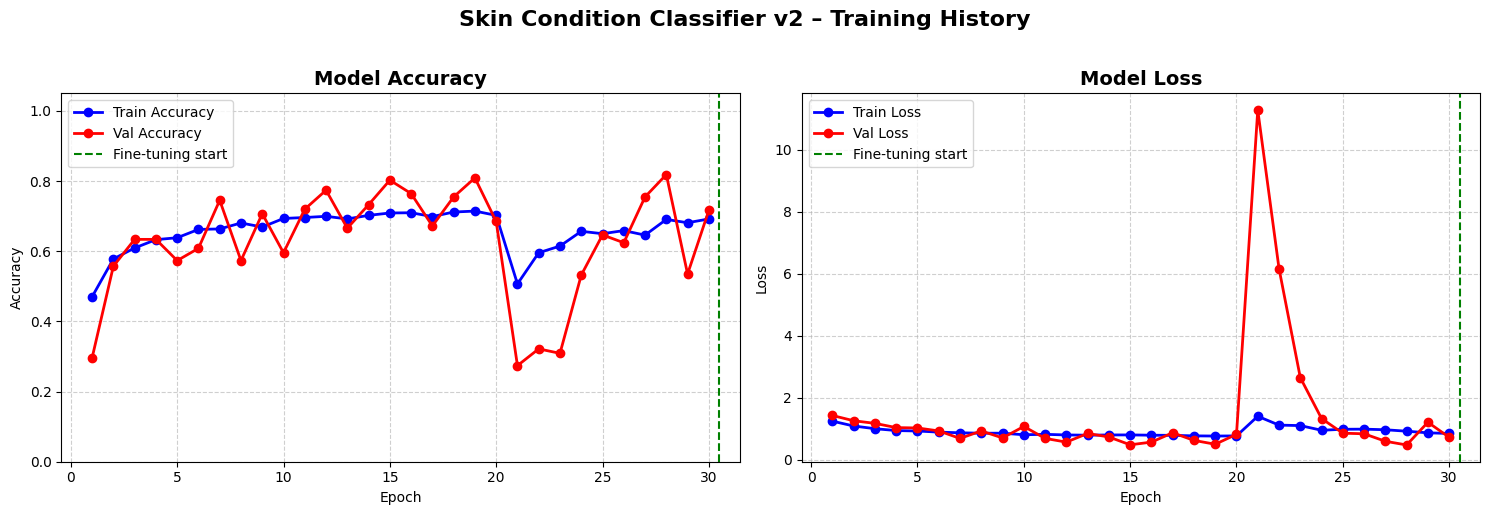

Plot saved as: training_history_v2.png


In [13]:
def plot_training_history(history_p1, history_p2=None):
    """
    Plots accuracy and loss curves.
    If history_p2 is provided, the two phases are concatenated and a divider
    line marks where fine-tuning began.
    """
    # ── Merge histories ───────────────────────────────────────────────────────
    acc      = history_p1.history['accuracy']
    val_acc  = history_p1.history['val_accuracy']
    loss     = history_p1.history['loss']
    val_loss = history_p1.history['val_loss']

    if history_p2 is not None:
        acc      += history_p2.history['accuracy']
        val_acc  += history_p2.history['val_accuracy']
        loss     += history_p2.history['loss']
        val_loss += history_p2.history['val_loss']

    epochs      = range(1, len(acc) + 1)
    phase1_end  = len(history_p1.history['accuracy'])   # x-position of divider

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for ax, train_vals, val_vals, ylabel, title in zip(
        axes,
        [acc,  loss],
        [val_acc, val_loss],
        ['Accuracy', 'Loss'],
        ['Model Accuracy', 'Model Loss']
    ):
        ax.plot(epochs, train_vals, 'b-o', label=f'Train {ylabel}', linewidth=2)
        ax.plot(epochs, val_vals,   'r-o', label=f'Val {ylabel}',   linewidth=2)
        # Vertical dashed line at fine-tuning start
        if history_p2 is not None:
            ax.axvline(x=phase1_end + 0.5, color='green', linestyle='--',
                       linewidth=1.5, label='Fine-tuning start')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)

    axes[0].set_ylim([0, 1.05])
    plt.suptitle('Skin Condition Classifier v2 – Training History',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('training_history_v2.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved as: training_history_v2.png")


plot_training_history(history_phase1, history_phase2)

## Step 9: Evaluate on Test Set

In [14]:
# Reset generator to ensure evaluation starts from the first image
test_generator.reset()

print("Evaluating model on test set...")
test_loss, test_accuracy = model.evaluate(
    test_generator,
    steps   = len(test_generator),
    verbose = 1
)

print("\n" + "=" * 45)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 45)

Evaluating model on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8375 - loss: 0.4556

  Test Loss     : 0.4556
  Test Accuracy : 83.75%


## Step 10: Detailed Per-Class Report

20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step
Classification Report:
              precision    recall  f1-score   support

        acne     0.8293    0.7907    0.8095        86
    alopecia     0.7097    0.7333    0.7213        60
      eczema     0.8000    0.8101    0.8050        79
     healthy     0.9583    0.9684    0.9634        95

    accuracy                         0.8375       320
   macro avg     0.8243    0.8256    0.8248       320
weighted avg     0.8379    0.8375    0.8375       320



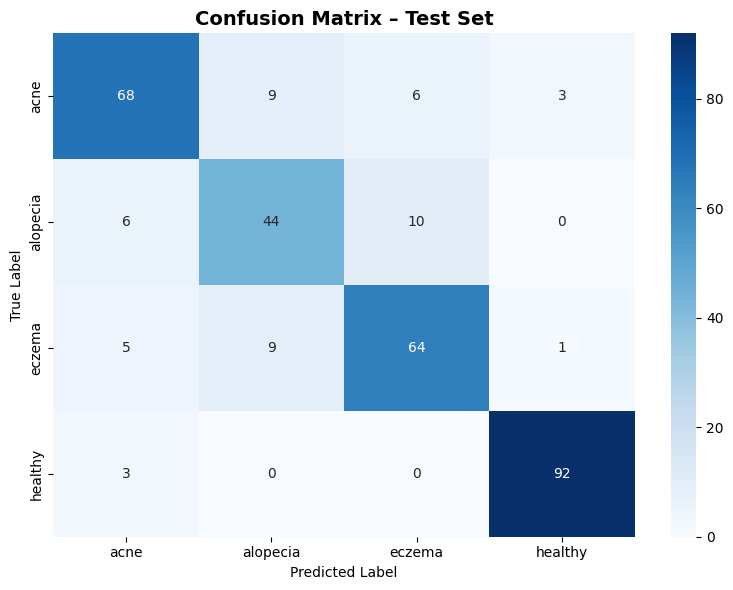

Confusion matrix saved as: confusion_matrix.png


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Get predictions ───────────────────────────────────────────────────────────
test_generator.reset()
y_pred_probs = model.predict(test_generator, steps=len(test_generator), verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_generator.classes

# Guard against shape mismatch when batch doesn't divide evenly
y_true = y_true[:len(y_pred)]

# ── Classification report ─────────────────────────────────────────────────────
print("Classification Report:")
print(classification_report(
    y_true, y_pred,
    target_names = CLASS_NAMES,
    digits       = 4
))

# ── Confusion matrix heatmap ──────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = CLASS_NAMES,
    yticklabels = CLASS_NAMES
)
plt.title('Confusion Matrix – Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as: confusion_matrix.png")

## Step 10b: Test-Time Augmentation (TTA) Evaluation
> **NEW**: an additional, separate evaluation pass only. Does NOT change training, preprocessing, image size, color mode, or model architecture. Step 9 and Step 10 above are untouched — this reuses the same `test_generator` and the same trained `model`.

Running Test-Time Augmentation evaluation...
  TTA batch 1/20 done.
  TTA batch 2/20 done.
  TTA batch 3/20 done.
  TTA batch 4/20 done.
  TTA batch 5/20 done.
  TTA batch 6/20 done.
  TTA batch 7/20 done.
  TTA batch 8/20 done.
  TTA batch 9/20 done.
  TTA batch 10/20 done.
  TTA batch 11/20 done.
  TTA batch 12/20 done.
  TTA batch 13/20 done.
  TTA batch 14/20 done.
  TTA batch 15/20 done.
  TTA batch 16/20 done.
  TTA batch 17/20 done.
  TTA batch 18/20 done.
  TTA batch 19/20 done.
  TTA batch 20/20 done.

Test Accuracy WITHOUT TTA: 83.75%
Test Accuracy WITH TTA: 84.38%

Classification Report (TTA):
              precision    recall  f1-score   support

        acne     0.7766    0.8488    0.8111        86
    alopecia     0.7895    0.7500    0.7692        60
      eczema     0.8194    0.7468    0.7815        79
     healthy     0.9588    0.9789    0.9688        95

    accuracy                         0.8438       320
   macro avg     0.8361    0.8312    0.8326       320
weighted

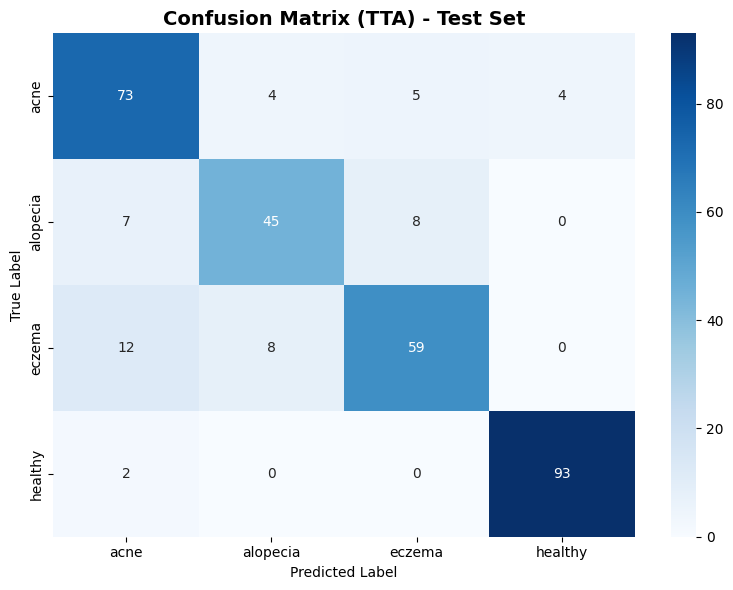


Confusion Matrix (TTA):
[[73  4  5  4]
 [ 7 45  8  0]
 [12  8 59  0]
 [ 2  0  0 93]]

Confusion matrix (TTA) saved as: confusion_matrix_tta.png


In [16]:
# ── Test-Time Augmentation (TTA) Evaluation ─────────────────────────────────
# For each test batch: predict on (a) the original batch, (b) a horizontally
# flipped batch, (c) a slightly zoomed-in batch (zoom_factor=1.05, clipped to
# [0,1]) — then average the 3 softmax probability vectors and take argmax.
#
# Preprocessing is untouched: test_generator already applies rescale=1./255
# (no preprocess_input(), no ImageNet normalization), and every TTA variant
# below operates on those already-rescaled 224x224 RGB batches — the zoom
# and flip are geometric transforms only, not a change to preprocessing.

zoom_factor_tta = 1.05


def zoom_in_batch(batch, zoom_factor):
    """
    Zoom in on a batch of images by `zoom_factor`, then center-crop back to
    the original height/width so the output shape matches the input. Uses
    tf.image (already a project dependency) rather than adding a new one.
    Bilinear resize can occasionally push values a hair outside [0, 1], so
    the result is explicitly clipped afterward, per spec.
    """
    orig_h, orig_w = batch.shape[1], batch.shape[2]
    new_h = int(round(orig_h * zoom_factor))
    new_w = int(round(orig_w * zoom_factor))
    resized = tf.image.resize(batch, (new_h, new_w))
    cropped = tf.image.resize_with_crop_or_pad(resized, orig_h, orig_w)
    return np.clip(cropped.numpy(), 0.0, 1.0)


def flip_batch_horizontal(batch):
    """
    True horizontal (left-right) flip for a BATCH of images.
    NOTE: plain np.fliplr always flips axis 1, which is the width axis for
    a single (H, W, C) image but the HEIGHT axis for a batched (N, H, W, C)
    array — calling np.fliplr directly on a batch would flip images
    upside-down instead of left-right. This performs the same left-right
    flip np.fliplr does, generalized correctly to the batched case.
    """
    return batch[:, :, ::-1, :]


def predict_with_tta(model, generator, zoom_factor):
    """
    Runs 3-variant TTA (original, horizontal flip, zoom) over every batch
    of `generator`, and returns:
        y_true         : ground-truth class indices, generator order
        y_pred_tta     : argmax of the averaged (3-variant) probabilities
        y_pred_no_tta  : argmax of the ORIGINAL-only probabilities
    """
    generator.reset()
    y_true_batches = []
    y_pred_tta_batches = []
    y_pred_no_tta_batches = []

    n_batches = len(generator)
    for step in range(n_batches):
        images, labels = next(generator)

        probs_original = model.predict(images, verbose=0)
        probs_flipped  = model.predict(flip_batch_horizontal(images), verbose=0)
        probs_zoomed   = model.predict(zoom_in_batch(images, zoom_factor), verbose=0)

        probs_avg = (probs_original + probs_flipped + probs_zoomed) / 3.0

        y_true_batches.append(np.argmax(labels, axis=1))
        y_pred_tta_batches.append(np.argmax(probs_avg, axis=1))
        y_pred_no_tta_batches.append(np.argmax(probs_original, axis=1))

        print(f"  TTA batch {step + 1}/{n_batches} done.")

    y_true        = np.concatenate(y_true_batches)
    y_pred_tta    = np.concatenate(y_pred_tta_batches)
    y_pred_no_tta = np.concatenate(y_pred_no_tta_batches)
    return y_true, y_pred_tta, y_pred_no_tta


print("Running Test-Time Augmentation evaluation...")
y_true_tta, y_pred_tta, y_pred_no_tta = predict_with_tta(model, test_generator, zoom_factor_tta)

test_accuracy_no_tta = np.mean(y_pred_no_tta == y_true_tta)
test_accuracy_tta    = np.mean(y_pred_tta == y_true_tta)

print("\n" + "=" * 55)
print(f"Test Accuracy WITHOUT TTA: {test_accuracy_no_tta * 100:.2f}%")
print(f"Test Accuracy WITH TTA: {test_accuracy_tta * 100:.2f}%")
print("=" * 55)

print("\nClassification Report (TTA):")
print(classification_report(y_true_tta, y_pred_tta, target_names=CLASS_NAMES, digits=4))

cm_tta = confusion_matrix(y_true_tta, y_pred_tta)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (TTA) - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_tta.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nConfusion Matrix (TTA):")
print(cm_tta)
print("\nConfusion matrix (TTA) saved as: confusion_matrix_tta.png")

## Step 11: Save the Final Model

In [18]:
# Save as Keras native format (.keras) – recommended for TF 2.x
FINAL_MODEL_PATH = r"C:\Users\GAURAV\Major Project Code\ml\trial\trial2\skin_model_final_v3_TTA_2.keras"
model.save(FINAL_MODEL_PATH)
print(f"Final model saved to:\n  {FINAL_MODEL_PATH}")

print("\n" + "=" * 50)
print("  Training Pipeline v2 Complete!")
print(f"  Final Test Accuracy : {test_accuracy * 100:.2f}%")
print("=" * 50)

# ── Save v3 TTA final model (SAME folder as the original final model) ──────
FINAL_MODEL_PATH_V3_TTA = os.path.join(os.path.dirname(FINAL_MODEL_PATH), "skin_model_final_v3_TTA.keras")
model.save(FINAL_MODEL_PATH_V3_TTA)
print(f"Final model (v3, TTA-evaluated) saved to:\n  {FINAL_MODEL_PATH_V3_TTA}")

Final model saved to:
  C:\Users\GAURAV\Major Project Code\ml\trial\trial2\skin_model_final_v3_TTA_2.keras

  Training Pipeline v2 Complete!
  Final Test Accuracy : 83.75%
Final model (v3, TTA-evaluated) saved to:
  C:\Users\GAURAV\Major Project Code\ml\trial\trial2\skin_model_final_v3_TTA.keras


## Step 12: Quick Inference Helper (Optional)

In [19]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_single_image(img_path, model, class_names, img_size=(224, 224)):
    """
    Loads a single image from disk and returns the predicted class + confidence.
    """
    img       = keras_image.load_img(img_path, target_size=img_size, color_mode='rgb')
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    probs           = model.predict(img_array, verbose=0)[0]
    predicted_idx   = np.argmax(probs)
    predicted_class = class_names[predicted_idx]
    confidence      = probs[predicted_idx]

    plt.figure(figsize=(5, 5))
    plt.imshow(keras_image.load_img(img_path, target_size=img_size))
    plt.axis('off')
    plt.title(
        f"Prediction: {predicted_class.upper()}\n"
        f"Confidence: {confidence * 100:.1f}%",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    return predicted_class, confidence


# ── Usage example ─────────────────────────────────────────────────────────────
# pred_class, conf = predict_single_image(
#     img_path    = r"C:\path\to\your\test_image.jpg",
#     model       = model,
#     class_names = CLASS_NAMES
# )
# print(f"Predicted: {pred_class}  |  Confidence: {conf:.2%}")

print("predict_single_image() helper is ready to use.")

predict_single_image() helper is ready to use.
